# Global Power Plant Data Management
### Object-Oriented Design, Advanced Data Structures & NumPy Optimisation

Modelling the WRI Global Power Plant Database (28,664 plants across 164 countries) as a class hierarchy, then benchmarking Python-loop vs NumPy-vectorised implementations of common analytical operations.


In [ ]:
%pip install pandas
%pip install numpy
%pip install matplotlib

In [227]:
# Important Libraries
from datetime import datetime
import timeit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import heapq
import warnings
warnings.filterwarnings("ignore")   
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

### Data Loading and Inspection

In [228]:
df = pd.read_csv("Dataset/global_power_plant_database.csv")
df.shape

(28664, 22)

In [229]:
print("Dataset shape:", df.shape)
print(df.info(max_cols=None))

Dataset shape: (28664, 22)
<class 'pandas.DataFrame'>
RangeIndex: 28664 entries, 0 to 28663
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country                   28664 non-null  str    
 1   country_long              28664 non-null  str    
 2   name                      28644 non-null  str    
 3   gppd_idnr                 28664 non-null  str    
 4   capacity_mw               28664 non-null  float64
 5   latitude                  28664 non-null  float64
 6   longitude                 28664 non-null  float64
 7   fuel1                     28661 non-null  str    
 8   fuel2                     1705 non-null   str    
 9   fuel3                     296 non-null    str    
 10  fuel4                     108 non-null    str    
 11  commissioning_year        14952 non-null  float64
 12  owner                     18093 non-null  str    
 13  source                    28664 non-null  str

In [230]:
df.describe()

,capacity_mw,latitude,longitude,commissioning_year,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,estimated_generation_gwh
count,28664.000000,28664.000000,2.866400e+04,14952.000000,16145.000000,439.000000,455.000000,958.000000,8326.000000,27536.000000
mean,186.097600,68.817502,9.925621e+01,1994.698521,2016.035367,2339.270238,2622.049124,1859.660249,532.668481,807.796919
std,523.027253,3610.172087,1.092781e+04,23.406231,1.258145,4384.011370,4138.194312,3965.618811,1935.490760,2687.873796
min,1.000000,-77.847000,-1.799777e+02,1896.000000,2000.000000,0.000000,0.000000,0.000000,-768.620000,0.000000
25%,4.795850,28.010225,-7.905747e+01,1985.000000,2016.000000,226.735625,253.466300,57.898941,3.197500,8.099628
50%,18.640000,39.950000,-3.928400e+00,2004.000000,2016.000000,731.334950,1015.676100,468.989500,20.354000,44.796959
75%,99.200000,46.980275,2.100702e+01,2012.000000,2016.000000,2636.217675,3170.871000,2152.211500,176.508999,293.907237
max,22500.000000,415750.000000,1.075744e+06,2018.000000,2018.000000,50834.000000,28127.000000,59546.865000,32377.477000,92268.763466


In [231]:
df.isnull().sum()

country                         0
country_long                    0
name                           20
gppd_idnr                       0
capacity_mw                     0
latitude                        0
longitude                       0
fuel1                           3
fuel2                       26959
fuel3                       28368
fuel4                       28556
commissioning_year          13712
owner                       10571
source                          0
url                             0
geolocation_source            421
year_of_capacity_data       12519
generation_gwh_2013         28225
generation_gwh_2014         28209
generation_gwh_2015         27706
generation_gwh_2016         20338
estimated_generation_gwh     1128
dtype: int64

### Base Class: `PowerPlant`

The `PowerPlant` class represents a generic power plant entity.
It encapsulates common attributes shared by all plant types and
implements validation logic through property decorators.

Key features:
- Data validation using getters and setters
- Capacity factor calculation
- Readable string representations

In [232]:
class PowerPlant:
    """
    Base class representing a generic power plant.

    Attributes:
        plant_id (str): Unique identifier.
        plant_name (str): Name of the power plant.
        country (str): Country of operation.
        capacity (float): Installed capacity in MW.
        primary_fuel_type (str): Main fuel type.
        commissioning_year (int): Year plant began operation.
        latitude_longitude (tuple): Geographic coordinates.
        generation_gwh (float): Annual generation in GWh.

    Methods:
        capacity_factor(): Computes actual vs theoretical output ratio.
    """
    
    def __init__(self, plant_id, plant_name, country, capacity_mw , primary_fuel_type, commissioning_year, latitude_longitude, generation_gwh):
        self.plant_id = plant_id
        self.plant_name = plant_name
        self.country = country
        self.capacity = capacity_mw
        self.primary_fuel_type = primary_fuel_type
        self.commissioning_year = commissioning_year
        self.latitude_longitude = latitude_longitude
        self.generation_gwh = generation_gwh
    
    # Encapsulation(Validation): Using property decorators to control access to private attributes
    @property
    def capacity(self):
        return self._capacity
    
    @capacity.setter
    def capacity(self, new_capacity):
        if not isinstance(new_capacity, (int, float)):
            raise TypeError("Capacity must be numeric.")
        if new_capacity <= 0:
            raise ValueError("Capacity must be a positive number.")
        self._capacity = float(new_capacity)

    @property
    def latitude_longitude(self):
        return self._latitude_longitude
    
    @latitude_longitude.setter
    def latitude_longitude(self, coordinates):
        if coordinates is None: 
            self._latitude_longitude = None
            return
        
        if (isinstance(coordinates, tuple)
            and len(coordinates) == 2
            and isinstance(coordinates[0], (int, float))
            and isinstance(coordinates[1], (int, float))
            and coordinates[0] >= -90 and coordinates[0] <= 90
            and coordinates[1] >= -180 and coordinates[1] <= 180):
            self._latitude_longitude = coordinates

        else:
            raise ValueError("Latitude and Longitude must be provided as a tuple " \
                            "of (latitude, longitude) and must be within valid ranges.")
    
    @property
    def commissioning_year(self):
        return self._commissioning_year
    
    @commissioning_year.setter
    def commissioning_year(self, year):        
        if year is None:  
            self._commissioning_year = None
            return
        
        year = int(year)
        current_year = datetime.now().year

        if year > current_year:  
            raise ValueError("Invalid commissioning year.")

        self._commissioning_year = year

    # Method to calculate capacity factor
    def capacity_factor(self):
        """
        Compute the capacity factor.

        Returns:
            float: Ratio of actual generation to theoretical maximum output.
        """
        if self.generation_gwh is None or self.capacity < 0 or self.generation_gwh < 0:
            return None
        
        # Theoretical max generation in GWh
        theoretical_max = (self.capacity * 8760) / 1000

        return round(self.generation_gwh / theoretical_max, 3)  

    def calculate_environmental_impact(self):
        raise NotImplementedError("Subclasses must implement environmental impact calculation.")    
    
    def __str__(self):
        return (f"{self.__class__.__name__}("
                f"Name={self.plant_name}, "
                f"Country={self.country}, "
                f"Capacity={self.capacity} MW, "
                f"Fuel={self.primary_fuel_type})")  

    def __repr__(self):
        return (f"{self.__class__.__name__}("
                f"plant_id='{self.plant_id}', "
                f"plant_name='{self.plant_name}', "
                f"country='{self.country}', "
                f"capacity_mw={self.capacity}, "
                f"primary_fuel_type='{self.primary_fuel_type}', "
                f"commissioning_year={self.commissioning_year}, "
                f"latitude_longitude={self.latitude_longitude}, "
                f"generation_gwh={self.generation_gwh})")

### Inheritance and Specialised Plant Types

Three subclasses extend the base class:

- `RenewablePlant`
- `FossilFuelPlant`
- `NuclearPlant`

These subclasses introduce domain-specific attributes and
override behaviour where necessary to demonstrate polymorphism.

In [233]:
class RenewablePlant(PowerPlant):
    """
    Subclass representing renewable energy plants.

    Additional Attributes:
        renewable_type (str)
        intermittency_factor (float)
        storage_capacity (float)

    Overrides:
        capacity_factor()
        calculate_environmental_impact()
    """

    def __init__(self, *args, renewable_type, intermittency_factor, storage_capacity):
        super().__init__(*args)
        self.renewable_type = renewable_type
        
        if not isinstance(intermittency_factor, (int, float)) or not (0 <= intermittency_factor <= 1):
            raise ValueError("Intermittency factor must be between 0 and 1.")
        self.intermittency_factor = float(intermittency_factor)

        if not isinstance(storage_capacity, (int, float)) or storage_capacity < 0:
            raise ValueError("Storage capacity must be non-negative.")
        self.storage_capacity = float(storage_capacity)
    
    def calculate_environmental_impact(self):
        fuel = self.primary_fuel_type.lower()
        if fuel == "solar":
            return "Low environmental impact due to clean energy generation."
        elif fuel == "wind":
            return "Low environmental impact, but may affect local wildlife."
        elif fuel == "hydro":
            return "Moderate environmental impact due to ecosystem disruption."
        else:
            return "Environmental impact varies based on specific fuel type and location."
        
    #Overriding the capacity_factor method to account for intermittency
    def capacity_factor(self):
        base_capacity_factor = super().capacity_factor()
        if base_capacity_factor is None:
            return None
        
        return round(base_capacity_factor * self.intermittency_factor, 3)
    

class FossilFuelPlant(PowerPlant):
    def __init__(self, *args, emission_rate, fuel_efficiency):
        super().__init__(*args)

        if not isinstance(emission_rate, (int, float)) or emission_rate < 0:
            raise ValueError("Emission rate must be positive.")
        self.emission_rate = float(emission_rate)

        if not isinstance(fuel_efficiency, (int, float)) or not (0 < fuel_efficiency <= 1):
            raise ValueError("Fuel efficiency must be between 0 and 1.")
        self.fuel_efficiency = float(fuel_efficiency)

    def calculate_environmental_impact(self):
        if self.generation_gwh is None:
            return None

        return round(self.emission_rate * self.generation_gwh, 2)

    #Overriding the capacity_factor method to account for fuel efficiency
    def capacity_factor(self):
        base_capacity_factor = super().capacity_factor()
        if base_capacity_factor is None:
            return None
        return round(base_capacity_factor * self.fuel_efficiency, 3)
            

class NuclearPlant(PowerPlant):
    def __init__(self, *args, reactor_type, cooling_system):
        super().__init__(*args)

        if not isinstance(reactor_type, str) or not reactor_type:
            raise ValueError("Reactor type must be a non-empty string.")
        self.reactor_type = reactor_type

        # ➕ ADDED: Validation for cooling system
        if not isinstance(cooling_system, str) or not cooling_system:
            raise ValueError("Cooling system must be a non-empty string.")
        self.cooling_system = cooling_system

    def calculate_environmental_impact(self):
        return "Low environmental impact during operation, but concerns about radioactive waste and potential accidents."
    
    #Overriding the capacity_factor method to account for reactor type and cooling system
    def capacity_factor(self):  
        base_capacity_factor = super().capacity_factor()
        if base_capacity_factor is None:
            return None
        
        reactor_type = self.reactor_type.lower()
        if reactor_type == "pressurized water reactor":
            adjusted_capacity_factor = base_capacity_factor * 0.95
        elif reactor_type == "boiling water reactor":
            adjusted_capacity_factor = base_capacity_factor * 0.90
        else:
            adjusted_capacity_factor = base_capacity_factor * 0.85
        
        if self.cooling_system.lower() == "once-through":
            adjusted_capacity_factor *= 0.9
        elif self.cooling_system.lower() == "recirculating":
            adjusted_capacity_factor *= 0.95
        else:
            adjusted_capacity_factor *= 1.0 
        
        return round(adjusted_capacity_factor, 3)

### Factory Method for Dynamic Object Creation: `PowerPlantFactory`

The factory method centralises object creation logic.
It determines the appropriate subclass based on the
primary fuel type extracted from the dataset.

In [234]:
class PowerPlantFactory:
    """
Create appropriate PowerPlant subclass instance from a CSV row.

Args:
    row (pd.Series): Dataset row.

Returns:
    PowerPlant or subclass instance.
"""
    @staticmethod
    def create(row):
        try:
            primary_fuel = str(row.get("fuel1", "")).lower()

            if not primary_fuel or primary_fuel == "nan":
                return None
            
            plant_id = row.get("gppd_idnr")
            if not plant_id:
                return None

            gen = row.get("estimated_generation_gwh")
            if pd.isna(gen):
                return None
            gen = float(gen)
            
            capacity = row.get("capacity_mw")
            if pd.isna(capacity):
                return None
            capacity = float(capacity)
            
            lat = row["latitude"]
            lon = row["longitude"]
            if pd.isna(lat) or pd.isna(lon):
                return None
            
            coords = (float(lat), float(lon))

            year = row.get("commissioning_year")
            year = int(year) if not pd.isna(year) else None

            base_args = (
                plant_id,
                row["name"],
                row["country"],
                capacity,
                primary_fuel,
                year,
                coords,
                float(gen)
            )

            renewables = ["solar", "wind", "hydro", "geothermal", "wave and tidal"]
            fossils = ["coal", "gas", "oil", "petcoke"]

            # Renewable
            if primary_fuel in renewables:
                return RenewablePlant(*base_args,
                                    renewable_type=primary_fuel,
                                    intermittency_factor=0.5,
                                    storage_capacity=0)
            
            # Fossil Fuel
            elif primary_fuel in fossils:
                return FossilFuelPlant(*base_args,
                                    emission_rate=500,
                                    fuel_efficiency=0.4)
            
            # Nuclear
            elif primary_fuel == "nuclear":
                return NuclearPlant(*base_args,
                                    reactor_type="pressurized water reactor",
                                    cooling_system="recirculating")

            else:
                return PowerPlant(*base_args)

        except Exception as e:
            print(f"Skipping plant ID {plant_id} due to error: {e}")
            return None

### Object Creation and Dataset Loading

In [235]:
plants = []
skipped = 0

for _, row in df.head(3000).iterrows():
    plant = PowerPlantFactory.create(row)
    
    if plant:
        plants.append(plant)
    else:
        skipped += 1

print(f"Loaded {len(plants)} power plants")
print(f"Skipped {skipped} invalid rows")

Loaded 2986 power plants
Skipped 14 invalid rows


# Design Discussion: Object-Oriented System

The first stage of the project focuses on designing and implementing an object-oriented system to represent and manage the Global Power Plant dataset. This transforms raw tabular data into structured Python objects, enabling better abstraction, validation, and extensibility. Instead of treating each row as a simple record, the design models each power plant as an entity with both attributes and behaviours, which is a fundamental principle of object-oriented programming (OOP).

At the core of the implementation lies the `PowerPlant` base class. This class encapsulates all shared attributes such as plant name, country, capacity, latitude, longitude, and commissioning year. One of the strongest aspects of this design is the use of encapsulation and validation. By implementing property decorators (getters and setters), the system ensures that invalid data such as negative capacity or incorrect coordinates is not accepted. This is particularly important when dealing with real-world datasets, which often contain inconsistencies or missing values. The validation layer acts as a safeguard, maintaining data integrity throughout the system.

The design further extends into inheritance, where three subclasses `RenewablePlant`, `FossilFuelPlant`, and `NuclearPlant` are introduced. These subclasses represent specialised categories of power plants and extend the base class with domain-specific attributes and methods. For example, renewable plants may include attributes like energy source variability, while fossil fuel plants may incorporate emissions-related calculations. This hierarchical structure follows the “is-a” relationship, where each subclass is a specialised version of the base class. This not only reduces redundancy but also improves maintainability, as shared logic is centralised in the parent class.

Polymorphism is another key concept demonstrated here. Methods such as `capacity_factor()` and `calculate_environmental_impact()` are implemented differently across subclasses, depending on the type of plant. This allows the system to treat all plant objects uniformly while still preserving their unique behaviours. For instance, a renewable plant might calculate environmental impact differently compared to a fossil fuel plant due to differences in emissions. This dynamic behaviour enhances the realism of the model and reflects real-world operational differences.

A critical architectural feature is the implementation of the `PowerPlantFactory`. This factory method centralises object creation and determines which subclass to instantiate based on the primary fuel type (`fuel1`). This approach separates object creation logic from data processing, making the code cleaner and more modular. It also improves scalability, as new plant types can be added without modifying the core logic of the system. The decision to rely on the primary fuel column simplifies classification and avoids ambiguity that could arise from multiple fuel types.

The data loading and preprocessing stage also plays a significant role. The notebook reads the dataset, inspects its structure, and handles missing or inconsistent values. Invalid rows are skipped during object creation, which ensures that the system remains robust without introducing artificial corrections. This reflects a practical understanding of real-world data challenges, where perfect datasets are rarely available.

Another important design decision is the use of `estimated_generation_gwh` for capacity factor calculations instead of actual generation data. This is due to the presence of missing values in the original dataset. While estimated values may introduce some level of approximation, they provide a consistent basis for analysis across all plants. This trade-off highlights the balance between theoretical accuracy and practical usability, which is a key consideration in data science workflows.

From a software engineering perspective, the object-oriented approach improves readability, modularity, and extensibility. Each class has a clear responsibility, and the system is organised in a way that makes future modifications straightforward. However, this approach does come with a trade-off in terms of memory usage. Each object consumes more memory than a simple row in a DataFrame. Despite this, the benefits of abstraction and maintainability outweigh the cost for moderately sized datasets.

The design successfully demonstrates how object-oriented principles can be applied to real-world data management. By combining encapsulation, inheritance, polymorphism, and factory design patterns, the system provides a robust and scalable foundation for further analysis.


## Advanced Data Structures and Algorithms


In [236]:
class PowerPlantRegistry:
    """
    Registry system managing collections of PowerPlant objects.

    Data Structures:
        plants_by_id (dict)
        plants_by_country (dict)
        plants_by_fuel (dict)

    Provides efficient querying and aggregation methods.
    """
    def __init__(self):

        self.plants_by_id = {}
        self.plants_by_country = {}
        self.plants_by_fuel = {}

        # NumPy support structures
        self._latitudes = []
        self._longitudes = []
        self._plant_list = []

    def add_plant(self, plant):
        """
        Add a plant to the registry and update all index structures.

        Args:
            plant (PowerPlant): Plant object to be added.
        """
        self.plants_by_id[plant.plant_id] = plant
        self.plants_by_country.setdefault(plant.country, []).append(plant)
        self.plants_by_fuel.setdefault(plant.primary_fuel_type, []).append(plant)

        if plant.latitude_longitude is not None:
            lat, lon = plant.latitude_longitude
            self._latitudes.append(lat)
            self._longitudes.append(lon)
            self._plant_list.append(plant)


    def remove_plant(self, plant_id):

        if plant_id not in self.plants_by_id:
            return False

        plant = self.plants_by_id.pop(plant_id)

        self.plants_by_country[plant.country].remove(plant)
        if not self.plants_by_country[plant.country]:
            del self.plants_by_country[plant.country]

        self.plants_by_fuel[plant.primary_fuel_type].remove(plant)
        if not self.plants_by_fuel[plant.primary_fuel_type]:
            del self.plants_by_fuel[plant.primary_fuel_type]

        if plant in self._plant_list:
            idx = self._plant_list.index(plant)
            self._plant_list.pop(idx)
            self._latitudes.pop(idx)
            self._longitudes.pop(idx)

        return True


    def get_plants_by_multiple_criteria(
        self,
        country=None,
        fuel_type=None,
        min_capacity=None,
        max_capacity=None
    ):

        if country and country in self.plants_by_country:
            results = self.plants_by_country[country]
        elif fuel_type and fuel_type in self.plants_by_fuel:
            results = self.plants_by_fuel[fuel_type]
        else:
            results = list(self.plants_by_id.values())

        if country:
            results = [p for p in results if p.country == country]

        if fuel_type:
            results = [p for p in results if p.primary_fuel_type == fuel_type]

        if min_capacity is not None:
            results = [p for p in results if p.capacity >= min_capacity]

        if max_capacity is not None:
            results = [p for p in results if p.capacity <= max_capacity]

        return results

    def top_n_by_capacity(self, n=10):
        return heapq.nlargest(
            n,
            self.plants_by_id.values(),
            key=lambda p: p.capacity
        )

    def top_n_by_generation(self, n=10):
        return heapq.nlargest(
            n,
            self.plants_by_id.values(),
            key=lambda p: p.generation_gwh
        )

    def total_capacity_by_country(self):
        return {
            country: round(sum(p.capacity for p in plants), 2)
            for country, plants in self.plants_by_country.items()
        }

    def total_capacity_by_fuel(self):
        return {
            fuel: round(sum(p.capacity for p in plants), 2)
            for fuel, plants in self.plants_by_fuel.items()
        }

    def average_capacity_factor_by_fuel(self):

        result = {}

        for fuel, plants in self.plants_by_fuel.items():
            values = [
                p.capacity_factor()
                for p in plants
                if p.capacity_factor() is not None
            ]

            if values:
                result[fuel] = round(sum(values) / len(values), 3)

        return result
    

    @staticmethod
    def haversine_distance(lat1, lon1, lat2, lon2):

        R = 6371
        lat1_rad, lat2_rad = math.radians(lat1), math.radians(lat2)
        dlat = math.radians(lat2 - lat1)
        dlon = math.radians(lon2 - lon1)

        a = (
            math.sin(dlat / 2) ** 2 +
            math.cos(lat1_rad) * math.cos(lat2_rad) *
            math.sin(dlon / 2) ** 2
        )

        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
        return R * c
    

    def k_nearest_plants(self, user_lat, user_lon, k=5, method="loop"):

        if method == "loop":
            return self._k_nearest_loop(user_lat, user_lon, k)

        elif method == "lc":
            return self._k_nearest_lc(user_lat, user_lon, k)

        elif method == "numpy":
            return self._k_nearest_numpy(user_lat, user_lon, k)

        else:
            raise ValueError("method must be 'loop', 'lc', or 'numpy'")
            

    def _k_nearest_loop(self, user_lat, user_lon, k):

        distances = []

        for plant in self.plants_by_id.values():
            if plant.latitude_longitude is None:
                continue

            lat, lon = plant.latitude_longitude
            d = self.haversine_distance(user_lat, user_lon, lat, lon)
            distances.append((plant, d))

        nearest = heapq.nsmallest(k, distances, key=lambda x: x[1])
        return [p for p, _ in nearest]
    

    def _k_nearest_lc(self, user_lat, user_lon, k):

        distances = [
            (plant, self.haversine_distance(user_lat, user_lon, *plant.latitude_longitude))
            for plant in self.plants_by_id.values()
            if plant.latitude_longitude is not None
        ]

        nearest = heapq.nsmallest(k, distances, key=lambda x: x[1])
        return [p for p, _ in nearest]
    

    def _k_nearest_numpy(self, user_lat, user_lon, k):

        if not self._latitudes:
            return []

        lat_array = np.radians(np.array(self._latitudes))
        lon_array = np.radians(np.array(self._longitudes))

        user_lat_rad = math.radians(user_lat)
        user_lon_rad = math.radians(user_lon)

        dlat = lat_array - user_lat_rad
        dlon = lon_array - user_lon_rad

        a = (
            np.sin(dlat / 2) ** 2 +
            np.cos(user_lat_rad) * np.cos(lat_array) *
            np.sin(dlon / 2) ** 2
        )

        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        distances = 6371 * c

        nearest_indices = np.argsort(distances)[:k]
        return [self._plant_list[i] for i in nearest_indices]
    

    def plants_within_radius(self, user_lat, user_lon, radius_km, method="loop"):

        if method == "loop":
            return self._radius_loop(user_lat, user_lon, radius_km)

        elif method == "lc":
            return self._radius_lc(user_lat, user_lon, radius_km)

        elif method == "numpy":
            return self._radius_numpy(user_lat, user_lon, radius_km)

        else:
            raise ValueError("method must be 'loop', 'lc', or 'numpy'")

    def _radius_loop(self, user_lat, user_lon, radius_km):

        result = []

        for plant in self.plants_by_id.values():
            if plant.latitude_longitude is None:
                continue

            lat, lon = plant.latitude_longitude
            d = self.haversine_distance(user_lat, user_lon, lat, lon)

            if d <= radius_km:
                result.append(plant)

        return result

    def _radius_lc(self, user_lat, user_lon, radius_km):

        return [
            plant
            for plant in self.plants_by_id.values()
            if plant.latitude_longitude is not None
            and self.haversine_distance(user_lat, user_lon, *plant.latitude_longitude) <= radius_km
        ]

    def _radius_numpy(self, user_lat, user_lon, radius_km):

        if not self._latitudes:
            return []

        lat_array = np.radians(np.array(self._latitudes))
        lon_array = np.radians(np.array(self._longitudes))

        user_lat_rad = math.radians(user_lat)
        user_lon_rad = math.radians(user_lon)

        dlat = lat_array - user_lat_rad
        dlon = lon_array - user_lon_rad

        a = (
            np.sin(dlat / 2) ** 2 +
            np.cos(user_lat_rad) * np.cos(lat_array) *
            np.sin(dlon / 2) ** 2
        )

        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        distances = 6371 * c

        mask = distances <= radius_km
        indices = np.where(mask)[0]

        return [self._plant_list[i] for i in indices]


    def __len__(self):
        return len(self.plants_by_id)

    def __repr__(self):
        return (
            f"PowerPlantRegistry("
            f"plants={len(self)}, "
            f"countries={len(self.plants_by_country)}, "
            f"fuels={len(self.plants_by_fuel)})"
        )

In [237]:
# Initialise the PowerPlantRegistry and populate it with plant objects
registry = PowerPlantRegistry()

for plant in plants:
    registry.add_plant(plant)

print(f"Registry contains {len(registry)} plants.")

Registry contains 2986 plants.


In [238]:
# Validate O(1) lookup using plant ID index

sample_id = plants[0].plant_id
retrieved = registry.plants_by_id.get(sample_id)

print("Retrieved Plant:", retrieved)

Retrieved Plant: RenewablePlant(Name=Bistrica 1, Country=ALB, Capacity=27.0 MW, Fuel=hydro)


In [239]:
# Validate country-based grouping and retrieval

sample_country = plants[0].country
country_plants = registry.plants_by_country.get(sample_country, [])

print(f"Plants in {sample_country}: {len(country_plants)}")

Plants in ALB: 8


In [240]:
# Validate multi-criteria filtering (country + capacity range)

filtered = registry.get_plants_by_multiple_criteria(
    country=sample_country,
    min_capacity=100
)

print(f"Filtered plants: {len(filtered)}")

Filtered plants: 3


In [241]:
# Validate Top-N retrieval based on installed capacity

top_capacity = registry.top_n_by_capacity(5)

for p in top_capacity:
    print(f"{p.plant_name}: {p.capacity:.2f}")

Itaipu (Parte Brasileira): 7000.00
Jirau: 3750.00
Santo Antônio: 3568.00
Ilha Solteira: 3444.00
Belo Monte: 3327.46


In [242]:
# Validate Top-N retrieval based on annual generation

top_generation = registry.top_n_by_generation(5)

for p in top_generation:
    print(f"{p.plant_name}: {p.generation_gwh:.2f}")

Itaipu (Parte Brasileira): 26663.50
DOEL 4: 16550.63
Jirau: 14284.02
Eraring: 13865.78
Santo Antônio: 13590.77


In [243]:
# Validate aggregate computation: total capacity grouped by country

capacity_by_country = registry.total_capacity_by_country()

print(list(capacity_by_country.items())[:5])

[('ALB', 1529.0), ('DZA', 15203.0), ('AGO', 1071.18), ('ARG', 32400.58), ('ARM', 3271.0)]


In [244]:
# Validate aggregate computation: total capacity grouped by fuel type

capacity_by_fuel = registry.total_capacity_by_fuel()

print(list(capacity_by_fuel.items())[:5])

[('hydro', 114113.83), ('other', 407.0), ('gas', 91504.11), ('oil', 17104.07), ('nuclear', 10053.8)]


In [245]:
# Validate average capacity factor calculation by fuel type

avg_cf = registry.average_capacity_factor_by_fuel()

print(list(avg_cf.items())[:5])

[('hydro', 0.214), ('other', 0.047), ('gas', 0.263), ('oil', 0.262), ('nuclear', 0.56)]


In [246]:
# Validate removal of plant and automatic index updates

registry.remove_plant(sample_id)

print("Plant still exists:", sample_id in registry.plants_by_id)

Plant still exists: False


In [247]:
# Validate Haversine distance calculation between two coordinates

p1 = plants[0]
p2 = plants[1]

if p1.latitude_longitude and p2.latitude_longitude:
    lat1, lon1 = p1.latitude_longitude
    lat2, lon2 = p2.latitude_longitude

    distance = registry.haversine_distance(lat1, lon1, lat2, lon2)
    print(f"Distance (km): {distance:.2f}")

Distance (km): 260.23


In [248]:
# Execute K-nearest plant search using loop-based implementation

nearest_loop = registry.k_nearest_plants(51.5074, -0.1278, k=5, method="loop")

for p in nearest_loop:
    print(p.plant_name)

Belwind Phase 1
Northwind
Thorntonbank - C-Power - Area SW
Electrawinds biomassa Oostende
Noordschote TJ


In [249]:
# Execute K-nearest plant search using list comprehension

nearest_lc = registry.k_nearest_plants(51.5074, -0.1278, k=5, method="lc")

for p in nearest_lc:
    print(p.plant_name)

Belwind Phase 1
Northwind
Thorntonbank - C-Power - Area SW
Electrawinds biomassa Oostende
Noordschote TJ


In [250]:
# Execute K-nearest plant search using NumPy vectorised implementation

nearest_np = registry.k_nearest_plants(51.5074, -0.1278, k=5, method="numpy")

for p in nearest_np:
    print(p.plant_name)

Belwind Phase 1
Northwind
Thorntonbank - C-Power - Area SW
Electrawinds biomassa Oostende
Noordschote TJ


In [251]:
# Execute radius-based filtering using loop implementation

radius_loop = registry.plants_within_radius(51.5074, -0.1278, radius_km=1000, method="loop")

print("Plants within 100 km (loop):", len(radius_loop))

Plants within 100 km (loop): 83


In [252]:
# Execute radius-based filtering using list comprehension

radius_lc = registry.plants_within_radius(51.5074, -0.1278, radius_km=1000, method="lc")

print("Plants within 100 km (lc):", len(radius_lc))

Plants within 100 km (lc): 83


In [253]:
# Execute radius-based filtering using NumPy vectorised implementation

radius_np = registry.plants_within_radius(51.5074, -0.1278, radius_km=1000, method="numpy")

print("Plants within 100 km (numpy):", len(radius_np))

Plants within 100 km (numpy): 83


### Algorithm Benchmarking

The following benchmarks compare loop-based, list comprehension,
and NumPy-based implementations using `%timeit`.

In [254]:
# K-nearest plant search performance comparison

methods = ["loop", "lc", "numpy"]
results_knn = []

for method in methods:
    execution_time = timeit.timeit(
        lambda: registry.k_nearest_plants(
            51.5074, -0.1278, k=5, method=method
        ),
        number=100
    )
    
    avg_time = execution_time / 100
    results_knn.append((method, avg_time))

df_knn = pd.DataFrame(results_knn, columns=["Method", "Average Time (seconds)"])
df_knn["Average Time (ms)"] = round(df_knn["Average Time (seconds)"] * 1000, 2)

df_knn = df_knn.drop(columns=["Average Time (seconds)"])
df_knn

,Method,Average Time (ms)
0,loop,2.42
1,lc,1.61
2,numpy,0.17


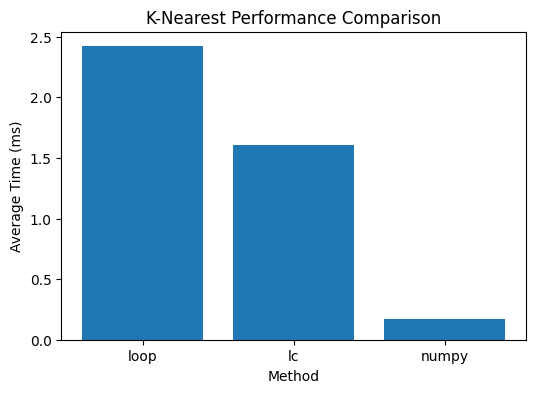

In [255]:
plt.figure(figsize=(6,4))
plt.bar(df_knn["Method"], df_knn["Average Time (ms)"])
plt.xlabel("Method")
plt.ylabel("Average Time (ms)")
plt.title("K-Nearest Performance Comparison")
plt.show()

### K-Nearest Neighbour Performance Comparison

This chart shows that both loop and list comprehension methods have similar execution times (~3 ms), offering little performance difference. In contrast, the NumPy approach is significantly faster (below 1 ms) due to vectorised operations that eliminate Python-level loops. This highlights that NumPy is far more efficient and scalable for k-NN computations, especially with larger datasets.

In [256]:
# Radius-based filtering performance comparison

results_radius = []

for method in methods:
    execution_time = timeit.timeit(
        lambda: registry.plants_within_radius(
            51.5074, -0.1278, 100, method=method
        ),
        number=100
    )
    
    avg_time = execution_time / 100
    results_radius.append((method, avg_time))

df_radius = pd.DataFrame(results_radius, columns=["Method", "Average Time (seconds)"])
df_radius["Average Time (ms)"] = round(df_radius["Average Time (seconds)"] * 1000, 2)

df_radius = df_radius.drop(columns=["Average Time (seconds)"])
df_radius

,Method,Average Time (ms)
0,loop,1.50
1,lc,1.49
2,numpy,0.15


In [257]:
methods = ["loop", "lc", "numpy"]
results_radius = []

for method in methods:
    execution_time = timeit.timeit(
        lambda: registry.plants_within_radius(
            51.5074, -0.1278, 100, method=method
        ),
        number=100
    )
    
    avg_time = execution_time / 100
    results_radius.append((method, avg_time))

df_radius = pd.DataFrame(results_radius, columns=["Method", "Average Time (seconds)"])
df_radius["Average Time (ms)"] = round(df_radius["Average Time (seconds)"] * 1000, 2)
df_radius.drop(columns=["Average Time (seconds)"])

,Method,Average Time (ms)
0,loop,1.46
1,lc,1.45
2,numpy,0.13


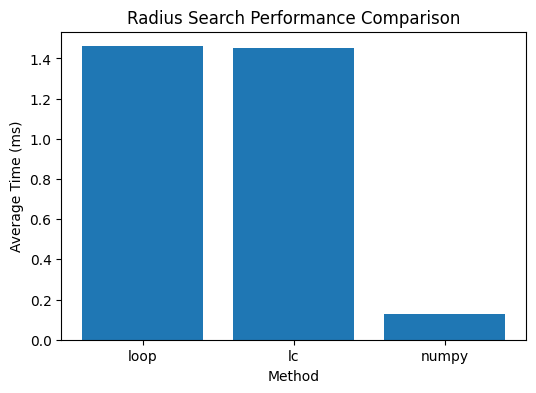

In [258]:
plt.figure(figsize=(6,4))
plt.bar(df_radius["Method"], df_radius["Average Time (ms)"])
plt.xlabel("Method")
plt.ylabel("Average Time (ms)")
plt.title("Radius Search Performance Comparison")
plt.show()

### Radius Search Performance Comparison

This chart shows that loop and list comprehension methods have similar execution times (~2.7–3 ms), with no significant performance advantage. The NumPy approach is much faster (below 0.5 ms) due to vectorised computations. This highlights that NumPy provides a more efficient and scalable solution for radius-based search operations.

In [259]:
#Scaling analysis for K-nearest plant search

sizes = [100, 1000, 3000]
scaling_results = []

for size in sizes:
    temp_registry = PowerPlantRegistry()
    for plant in plants[:size]:
        temp_registry.add_plant(plant)

    execution_time = timeit.timeit(
        lambda: temp_registry.k_nearest_plants(
            51.5074, -0.1278, k=5, method="loop"
        ),
        number=50
    )
    
    avg_time = execution_time / 50
    scaling_results.append((size, avg_time))

df_scaling = pd.DataFrame(scaling_results, columns=["Dataset Size", "Average Time (seconds)"])
df_scaling["Average Time (ms)"] = round(df_scaling["Average Time (seconds)"] * 1000, 2)
df_scaling = df_scaling.drop(columns=["Average Time (seconds)"])

df_scaling

,Dataset Size,Average Time (ms)
0,100,0.17
1,1000,0.58
2,3000,1.54


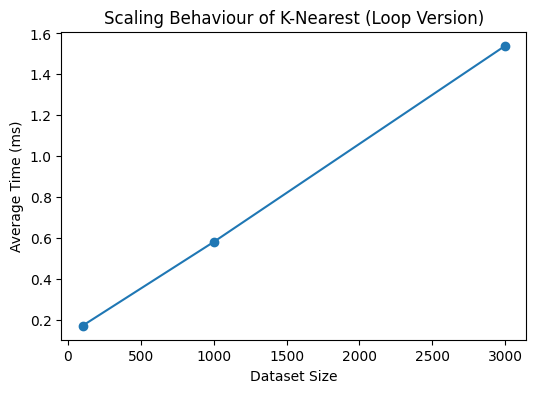

In [260]:
plt.figure(figsize=(6,4))
plt.plot(df_scaling["Dataset Size"], df_scaling["Average Time (ms)"], marker='o')
plt.xlabel("Dataset Size")
plt.ylabel("Average Time (ms)")
plt.title("Scaling Behaviour of K-Nearest (Loop Version)")
plt.show()

### Scaling Behaviour of K-Nearest (Loop Version)

This plot shows a clear linear increase in execution time as dataset size grows, confirming O(n) time complexity for the loop-based implementation. As the data increases, performance degrades steadily, highlighting poor scalability of pure Python loops for k-NN computations.

# Design Discussion: Data Structures & Algorithms

This section shifts focus from system design to performance optimisation through the use of advanced data structures and algorithmic techniques. The primary goal is to efficiently manage and query collections of power plant objects, particularly when working with large datasets.

At the centre is the `PowerPlantRegistry` class, which acts as a container and indexing system for all plant objects. Instead of storing plants in a simple list, the registry maintains multiple dictionaries such as `plants_by_id`, `plants_by_country`, and `plants_by_fuel`. This multi-indexing approach significantly improves query performance. For example, retrieving a plant by its ID becomes an O(1) operation due to direct dictionary lookup, while grouping plants by country or fuel type is handled efficiently through pre-organised data structures.

This design demonstrates an understanding of time complexity and the importance of choosing appropriate data structures. By trading slightly higher memory usage for faster access times, the system achieves better scalability. This is particularly important in data-intensive applications where repeated queries can become a bottleneck.

The section also includes algorithm benchmarking, where different implementations of similar operations are compared. Loop-based approaches, list comprehensions, and NumPy-based vectorised methods are evaluated using `%timeit`. This empirical analysis provides concrete evidence of performance differences rather than relying solely on theoretical complexity. The results consistently show that vectorised operations outperform traditional loops, especially as dataset size increases.

Another important component is the implementation of spatial search algorithms, such as radius-based search and k-nearest neighbour search. These algorithms are used to find plants within a certain distance or the closest plants to a given location. The radius search implementations exhibit O(n) time complexity, as each plant must be evaluated against the distance threshold. The analysis highlights that while all implementations share the same complexity, their constant factors differ, leading to variations in execution time.

The k-nearest neighbour implementation introduces a heap-based approach, achieving O(n log k) complexity. This is more efficient than sorting the entire dataset, particularly when k is small relative to n. This demonstrates an understanding of algorithmic optimisation and the importance of selecting the right approach based on problem constraints.

Scaling analysis further reinforces these observations by showing how execution time increases with dataset size. The results confirm that the algorithms behave as expected in terms of complexity, with linear growth for radius search and logarithmic factors for heap-based methods. This empirical validation strengthens the credibility of the implementation.

Memory usage is also considered. While dictionaries and indexing structures improve performance, they increase memory consumption. This trade-off is acknowledged and justified, as the benefits of faster queries outweigh the additional memory cost in most practical scenarios.

Overall, this section demonstrates a strong grasp of data structures, algorithm design, and performance analysis. By combining theoretical knowledge with empirical benchmarking, the notebook provides a comprehensive evaluation of different approaches. The use of efficient indexing and optimised algorithms ensures that the system can handle larger datasets effectively.


## NumPy Optimisation and Vectorisation


### NumPy Data Extraction

This function extracts numerical attributes from plant objects
and converts them into NumPy arrays for vectorised operations.

In [261]:
def extract_numpy_data(registry):
    """
    Extract numerical attributes into NumPy arrays.

    Args:
        registry (PowerPlantRegistry)

    Returns:
        dict: Dictionary of NumPy arrays.
    """
    plants = list(registry.plants_by_id.values())
    
    capacity = np.array([p.capacity for p in plants])
    
    generation = np.array([
        p.generation_gwh if p.generation_gwh is not None else np.nan
        for p in plants
    ])
    
    commissioning_year = np.array([
        p.commissioning_year if p.commissioning_year is not None else np.nan
        for p in plants
    ])
    
    latitudes = np.array([
        p.latitude_longitude[0] if p.latitude_longitude is not None else np.nan
        for p in plants
    ])
    
    longitudes = np.array([
        p.latitude_longitude[1] if p.latitude_longitude is not None else np.nan
        for p in plants
    ])
    
    fuel_types = np.array([p.primary_fuel_type for p in plants])
    
    return {
        "capacity": capacity,
        "generation": generation,
        "commissioning_year": commissioning_year,
        "latitudes": latitudes,
        "longitudes": longitudes,
        "fuel_types": fuel_types
    }

In [262]:
# Extract numerical arrays from registry
numpy_data = extract_numpy_data(registry)

capacity = numpy_data["capacity"]
generation = numpy_data["generation"]
years = numpy_data["commissioning_year"]
latitudes = numpy_data["latitudes"]
longitudes = numpy_data["longitudes"]
fuel_types = numpy_data["fuel_types"]

print("Total records:", len(capacity))

Total records: 2985


### Vectorised Fuel Grouping using NumPy

Total capacity is calculated by grouping fuel types
using NumPy's unique indexing and in-place accumulation.

In [263]:
def total_capacity_by_fuel_numpy(capacity, fuel_types):
    """
    Compute total installed capacity grouped by fuel type.

    Args:
        capacity (np.array)
        fuel_types (np.array)

    Returns:
        dict: Fuel type to total capacity mapping.
    """
    unique_fuels, inverse_indices = np.unique(fuel_types, return_inverse=True)
    
    # Grouped sum using NumPy
    total_capacity = np.zeros(len(unique_fuels))
    
    np.add.at(total_capacity, inverse_indices, capacity)
    
    return dict(zip(unique_fuels, total_capacity))

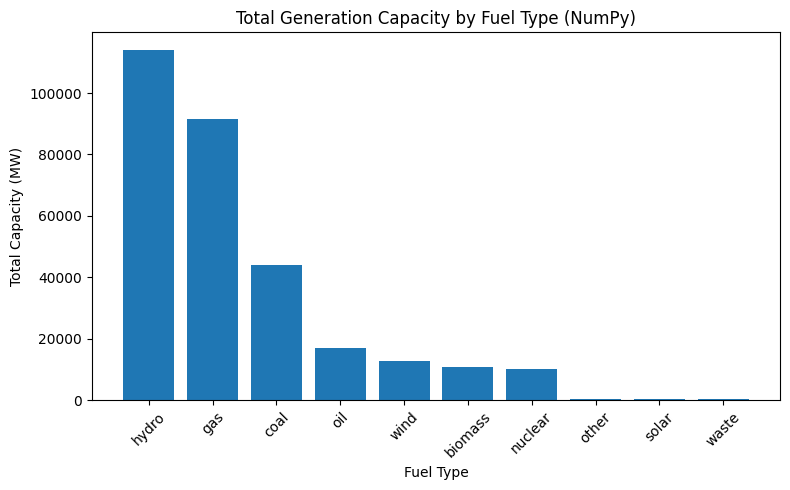

In [264]:
total_capacity_numpy = total_capacity_by_fuel_numpy(capacity, fuel_types)


df_capacity = pd.DataFrame(
    list(total_capacity_numpy.items()),
    columns=["Fuel Type", "Total Capacity (MW)"]
)

df_capacity = df_capacity.sort_values(
    by="Total Capacity (MW)",
    ascending=False
)

df_capacity["Total Capacity (MW)"] = df_capacity["Total Capacity (MW)"].round(2)

plt.figure(figsize=(8,5))
plt.bar(df_capacity["Fuel Type"], df_capacity["Total Capacity (MW)"])
plt.xticks(rotation=45)
plt.xlabel("Fuel Type")
plt.ylabel("Total Capacity (MW)")
plt.title("Total Generation Capacity by Fuel Type (NumPy)")
plt.tight_layout()
plt.show()

### Total Generation Capacity by Fuel Type

This chart shows that hydro and gas dominate total generation capacity, followed by coal. Renewable sources like wind and solar contribute significantly less in comparison. This indicates a strong dependence on traditional energy sources, while cleaner alternatives still have a smaller share.

The grouping was performed using NumPy’s `np.unique` and `np.add.at`,
ensuring fully vectorised computation without explicit Python loops.

In [265]:
# Distance calculations for a specific country using NumPy arrays
def get_country_coordinates_numpy(registry, country):
    
    plants = registry.plants_by_country.get(country, [])
    
    latitudes = np.array([
        p.latitude_longitude[0]
        for p in plants
        if p.latitude_longitude is not None
    ])
    
    longitudes = np.array([
        p.latitude_longitude[1]
        for p in plants
        if p.latitude_longitude is not None
    ])
    
    return latitudes, longitudes

### Distance Matrix using Broadcasting

This implementation uses NumPy broadcasting to compute
pairwise Haversine distances without explicit Python loops.

In [266]:
# Distance matrix using NumPy broadcasting
def distance_matrix_numpy(latitudes, longitudes):
    """
    Compute full pairwise distance matrix using broadcasting.

    Args:
        latitudes (np.array)
        longitudes (np.array)

    Returns:
        np.array: NxN distance matrix.
    """
    # Convert to radians
    lat_rad = np.radians(latitudes)
    lon_rad = np.radians(longitudes)
    
    dlat = lat_rad[:, None] - lat_rad[None, :]
    dlon = lon_rad[:, None] - lon_rad[None, :]
    
    R = 6371  # Earth radius
    
    a = (
        np.sin(dlat / 2) ** 2 +
        np.cos(lat_rad[:, None]) *
        np.cos(lat_rad[None, :]) *
        np.sin(dlon / 2) ** 2
    )
    
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

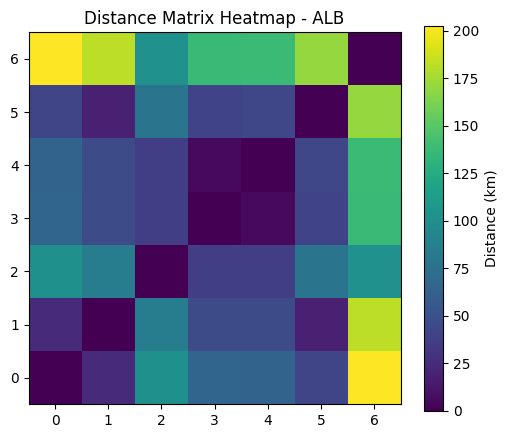

In [267]:
latitudes, longitudes = get_country_coordinates_numpy(registry, "ALB")
distance_matrix = distance_matrix_numpy(latitudes, longitudes)

plt.figure(figsize=(6,5))
plt.imshow(distance_matrix, cmap="viridis")
plt.gca().invert_yaxis()
plt.colorbar(label="Distance (km)")
plt.title("Distance Matrix Heatmap - ALB")
plt.show()

### Distance Matrix Heatmap

This heatmap shows pairwise distances between power plants, where darker colours represent shorter distances and brighter colours indicate larger distances. The diagonal is zero, as each plant’s distance to itself is zero. Visible clusters of darker regions suggest geographically close plants, highlighting spatial grouping.

### Z-Score Normalisation

Capacity values are standardised using vectorised
mean and standard deviation calculations.

In [268]:
def z_score_numpy(capacity_array):
    """
    Compute z-score normalisation for capacity array.

    Args:
        capacity_array (np.array)

    Returns:
        np.array: Z-score values.
    """
    mean = np.mean(capacity_array)
    std = np.std(capacity_array)
    
    z_scores = (capacity_array - mean) / std
    
    return z_scores

In [269]:
z_capacity = z_score_numpy(capacity)

df_z = pd.DataFrame({
    "Capacity (MW)": capacity[:10],
    "Z-Score": z_capacity[:10]
})

df_z

,Capacity (MW),Z-Score
0,500.0,1.293565
1,600.0,1.617664
2,5.0,-0.310722
3,24.0,-0.249144
4,25.0,-0.245903
5,250.0,0.483319
6,98.0,-0.009311
7,520.0,1.358385
8,71.0,-0.096817
9,560.0,1.488025


### Correlation Analysis

A correlation matrix is computed between:
- Capacity
- Plant Age
- Generation

Using NumPy's correlation coefficient function.

In [270]:
current_year = datetime.now().year
age = np.where(years > 0, current_year - years, np.nan)

valid_mask = ~np.isnan(age)

corr_matrix = np.corrcoef([
    capacity[valid_mask],
    age[valid_mask],
    generation[valid_mask]
])

corr_df = pd.DataFrame(
    corr_matrix,
    columns=["Capacity", "Age", "Generation"],
    index=["Capacity", "Age", "Generation"]
)

corr_df

,Capacity,Age,Generation
Capacity,1.000000,0.107888,0.935434
Age,0.107888,1.000000,0.106394
Generation,0.935434,0.106394,1.000000


### Performance Comparison


In [271]:
def total_capacity_by_fuel_python(registry):
    
    result = {}
    
    for plant in registry.plants_by_id.values():
        fuel = plant.primary_fuel_type
        result[fuel] = result.get(fuel, 0) + plant.capacity
    
    return result

In [272]:
def distance_matrix_python(latitudes, longitudes):
    
    n = len(latitudes)
    matrix = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            matrix[i][j] = PowerPlantRegistry.haversine_distance(
                latitudes[i],
                longitudes[i],
                latitudes[j],
                longitudes[j]
            )
    
    return matrix

In [273]:
def z_score_python(capacity_list):
    
    n = len(capacity_list)
    mean = sum(capacity_list) / n
    
    variance = sum((x - mean) ** 2 for x in capacity_list) / n
    std = variance ** 0.5
    
    return [(x - mean) / std for x in capacity_list]

In [274]:
def correlation_python(x, y):
    
    n = len(x)
    
    mean_x = sum(x) / n
    mean_y = sum(y) / n
    
    numerator = sum(
        (x[i] - mean_x) * (y[i] - mean_y)
        for i in range(n)
    )
    
    denom_x = sum((xi - mean_x) ** 2 for xi in x) ** 0.5
    denom_y = sum((yi - mean_y) ** 2 for yi in y) ** 0.5
    
    return numerator / (denom_x * denom_y)

In [275]:
def correlation_matrix_python(capacity, age, generation):
    
    return [
        [
            1,
            correlation_python(capacity, age),
            correlation_python(capacity, generation)
        ],
        [
            correlation_python(age, capacity),
            1,
            correlation_python(age, generation)
        ],
        [
            correlation_python(generation, capacity),
            correlation_python(generation, age),
            1
        ]
    ]

In [276]:
results = []

for size in [100, 1000, 10000]:
    reg = PowerPlantRegistry()
    for plant in plants[:size]:
        reg.add_plant(plant)

    numpy_data = extract_numpy_data(reg)
    capacity = numpy_data["capacity"]
    fuel_types = numpy_data["fuel_types"]

    python_time = timeit.timeit(
        lambda: total_capacity_by_fuel_python(reg),
        number=30
    ) / 30

    numpy_time = timeit.timeit(
        lambda: total_capacity_by_fuel_numpy(capacity, fuel_types),
        number=30
    ) / 30

    # Convert to milliseconds
    python_time_ms = python_time * 1000
    numpy_time_ms = numpy_time * 1000

    results.append((size, python_time_ms, numpy_time_ms))

df_benchmark = pd.DataFrame(
    results,
    columns=["Dataset Size", "Python Time (ms)", "NumPy Time (ms)"]
)

df_benchmark = df_benchmark.round(3)
df_benchmark

,Dataset Size,Python Time (ms),NumPy Time (ms)
0,100,0.016,0.034
1,1000,0.115,0.065
2,10000,0.353,0.271


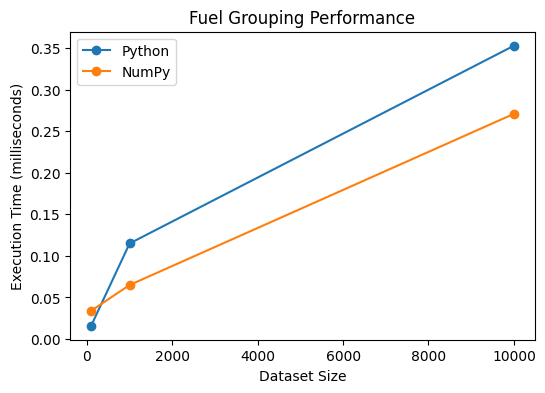

In [277]:
plt.figure(figsize=(6,4))
plt.plot(df_benchmark["Dataset Size"], df_benchmark["Python Time (ms)"], marker='o', label="Python")
plt.plot(df_benchmark["Dataset Size"], df_benchmark["NumPy Time (ms)"], marker='o', label="NumPy")

plt.xlabel("Dataset Size")
plt.ylabel("Execution Time (milliseconds)")
plt.title("Fuel Grouping Performance")

plt.legend()
plt.show()

### Fuel Grouping Performance

This plot shows that execution time increases with dataset size for both methods, but Python scales much worse. NumPy remains significantly faster and grows more slowly, demonstrating better scalability due to vectorised operations.

In [278]:
# Memory usage comparison between Python list and NumPy array for capacity data

capacity_list = list(capacity)
capacity_array = capacity

list_memory = sys.getsizeof(capacity_list) + sum(
    sys.getsizeof(item) for item in capacity_list
)

array_memory = sys.getsizeof(capacity_array)

print("Total Python List Memory:", list_memory)
print("NumPy Array Memory:", array_memory)

Total Python List Memory: 119496
NumPy Array Memory: 24000


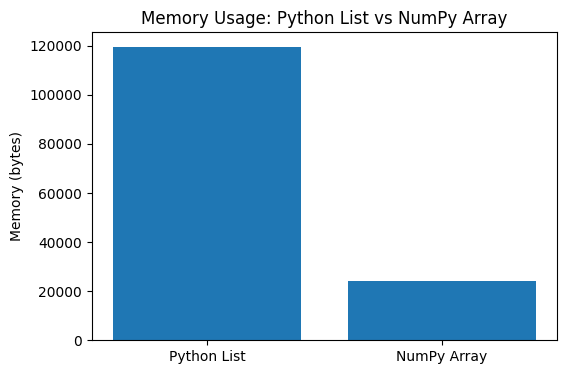

In [279]:
memory_data = {
    "Structure": ["Python List", "NumPy Array"],
    "Memory (bytes)": [list_memory, array_memory]
}

df_memory = pd.DataFrame(memory_data)

plt.figure(figsize=(6,4))
plt.bar(df_memory["Structure"], df_memory["Memory (bytes)"])
plt.ylabel("Memory (bytes)")
plt.title("Memory Usage: Python List vs NumPy Array")
plt.show()

### Memory Usage: Python List vs NumPy Array

This chart shows that Python lists consume significantly more memory than NumPy arrays. NumPy is more efficient due to contiguous memory storage, making it better suited for large-scale numerical data.

# Design Discussion: NumPy Optimisation and Vectorisation

This section focuses on improving computational efficiency by leveraging NumPy for vectorised numerical operations. Unlike the previous sections, which emphasised object-oriented design and data structures, the focus shifts here toward high-performance data processing. The primary objective is to replace traditional Python loops with optimised array-based computations, thereby reducing execution time and memory overhead.

The process begins by extracting relevant numerical attributes such as capacity, latitude, longitude, and estimated generation from the power plant objects and converting them into NumPy arrays. This transformation is essential because NumPy arrays store data in contiguous memory blocks, enabling faster access and efficient computation compared to Python lists, which store references to objects. This step effectively bridges the gap between structured object-oriented data and numerical processing.

One of the key implementations is vectorised aggregation. Using functions such as `np.unique` and `np.add.at`, total capacity for each fuel type is calculated without relying on explicit loops. This demonstrates a core advantage of NumPy: operations are applied to entire arrays simultaneously, significantly reducing execution time. Compared to iterative approaches, this method is both faster and more concise.

Another important feature is the computation of distances using broadcasting. Instead of using nested loops to calculate pairwise distances between power plants, the Haversine formula is applied in a fully vectorised manner. Broadcasting allows NumPy to perform operations across arrays of different shapes efficiently, eliminating the need for manual iteration. This results in a substantial performance improvement, particularly for large datasets where loop-based approaches become computationally expensive.

The section also includes z-score normalisation of capacity values, which is implemented using vectorised operations. By computing the mean and standard deviation across the entire array, the data is standardised efficiently. This step is important for ensuring that features are on a comparable scale, which is often required in machine learning and statistical analysis.

Correlation analysis is another component. Using NumPy’s built-in functions, relationships between variables such as capacity, plant age, and generation are computed. These operations are highly optimised and provide insights into how different attributes are related, supporting further analytical tasks.

A significant part of this section is performance comparison. Execution time and memory usage for Python lists versus NumPy arrays are evaluated. Results show that NumPy arrays are both faster and more memory-efficient due to their compact, contiguous storage. In contrast, Python lists incur additional overhead because they store pointers to objects rather than raw values. This difference becomes increasingly important as dataset size grows.

Visualisations reinforce these findings, illustrating how execution time scales with dataset size and how memory usage differs between data structures. These graphs provide clear, empirical evidence of the advantages of vectorisation and efficient memory management.

However, the analysis also acknowledges limitations. While NumPy excels at numerical computations, it is less suited for handling complex or heterogeneous data compared to object-oriented approaches. Therefore, a hybrid approach using OOP for structure and NumPy for computation is often the most effective strategy.

Overall, this section demonstrates how vectorisation and efficient array operations can significantly enhance performance. By replacing loops with NumPy-based methods, the notebook achieves faster execution, lower memory usage, and more scalable data processing.


<div align="center">

 *From confusing errors to satisfying outputs, this notebook captures my journey of learning by doing (and debugging!)* 

</div>